In [1]:
# import os
# # Force native CUDA instead of buggy cuDNN 9 binaries
# os.environ["TF_CUDNN_DISABLE"] = "1"
# os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
# os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true" 

import tensorflow as tf
# Disable JIT compilation to drop the XLA compiler layer completely
# tf.config.optimizer.set_jit(False)

import keras
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

2026-05-23 02:48:53.335313: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 02:48:53.357540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779484733.384862 3762907 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779484733.393981 3762907 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-23 02:48:53.421102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.__version__, keras.__version__

('2.18.0', '3.14.1')

In [4]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [6]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [7]:
batch_size = 16
epochs = 5
num_classes = pd.Series(y_train).nunique()
num_classes

10

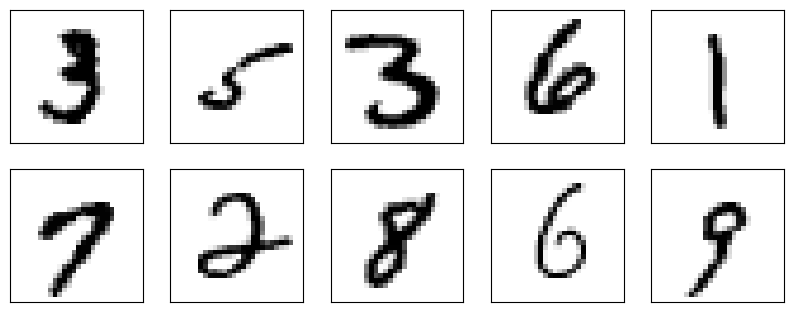

In [8]:
plt.figure(figsize=(10, 10))

for i in range(10, 20):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i,:,:], cmap=plt.cm.binary)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
x_train.ndim, type(x_train), x_train.dtype

(3, numpy.ndarray, dtype('uint8'))

In [11]:
# normalize the data
x_train = x_train/255.0
x_test = x_test/255.0

# adding a channel dimension
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [12]:
print(f"x_train: {x_train.shape},\nx_test: {x_test.shape},\nx_train_dimensions: {x_train.ndim},\nx_test_dimensions: {x_test.ndim},\ntype: {type(x_train)}")

x_train: (60000, 28, 28, 1),
x_test: (10000, 28, 28, 1),
x_train_dimensions: 4,
x_test_dimensions: 4,
type: <class 'numpy.ndarray'>


In [13]:
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(16, kernel_size=(3, 3),padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

I0000 00:00:1779484737.837255 3762907 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1739 MB memory:  -> device: 0, name: NVIDIA GeForce MX230, pci bus id: 0000:01:00.0, compute capability: 6.1


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        86,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,050 (340.04 KB)

 Trainable params: 87,050 (340.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])

In [16]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test), verbose=1)

Epoch 1/5


I0000 00:00:1779484740.330435 3763291 service.cc:148] XLA service 0x7eb84c008e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779484740.330516 3763291 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce MX230, Compute Capability 6.1
2026-05-23 02:49:00.375120: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779484740.458553 3763291 cuda_dnn.cc:529] Loaded cuDNN version 90300


  68/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.3162 - loss: 2.0015

2026-05-23 02:49:02.876198: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779484742.886776 3763291 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8701 - loss: 0.4154 - val_accuracy: 0.9677 - val_loss: 0.1093
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9342 - loss: 0.2146 - val_accuracy: 0.9741 - val_loss: 0.0773
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9471 - loss: 0.1712 - val_accuracy: 0.9782 - val_loss: 0.0680
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9526 - loss: 0.1501 - val_accuracy: 0.9807 - val_loss: 0.0619
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9579 - loss: 0.1316 - val_accuracy: 0.9818 - val_loss: 0.0590


In [17]:
model.evaluate(x_test, y_test, return_dict=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9818 - loss: 0.0590


{'accuracy': 0.9818000197410583, 'loss': 0.058998480439186096}

## Shap

In [19]:
background = x_train[(np.random.choice(x_train.shape[0], 100, replace=False))]
background.shape

(100, 28, 28, 1)

In [20]:
explainer = shap.DeepExplainer(model, background)

/home/naman/miniforge3/envs/mytf/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/naman/miniforge3/envs/mytf/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)


In [45]:
test_data = x_test[:10]
test_data.shape

(10, 28, 28, 1)

In [46]:
shap_data = explainer(test_data)

/home/naman/miniforge3/envs/mytf/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 28, 28, 1))']
  warnings.warn(msg)


In [47]:
shap_data.values.shape

(10, 28, 28, 1, 10)

(`samples` x `width` x `height` x `channels` x `shap values for each class`)

In [48]:
# for one class say class 2
shap_data.values[:,:,:,:,2].shape, shap_data.data[:,:,:,:].shape

((10, 28, 28, 1), (10, 28, 28, 1))

In [49]:
shap_value_list = []
for i in range(10):
    shap_value_list.append(shap_data.values[:,:,:,:,i])

In [50]:
len(shap_value_list)

10

In [51]:
shap_value_list[0].shape

(10, 28, 28, 1)

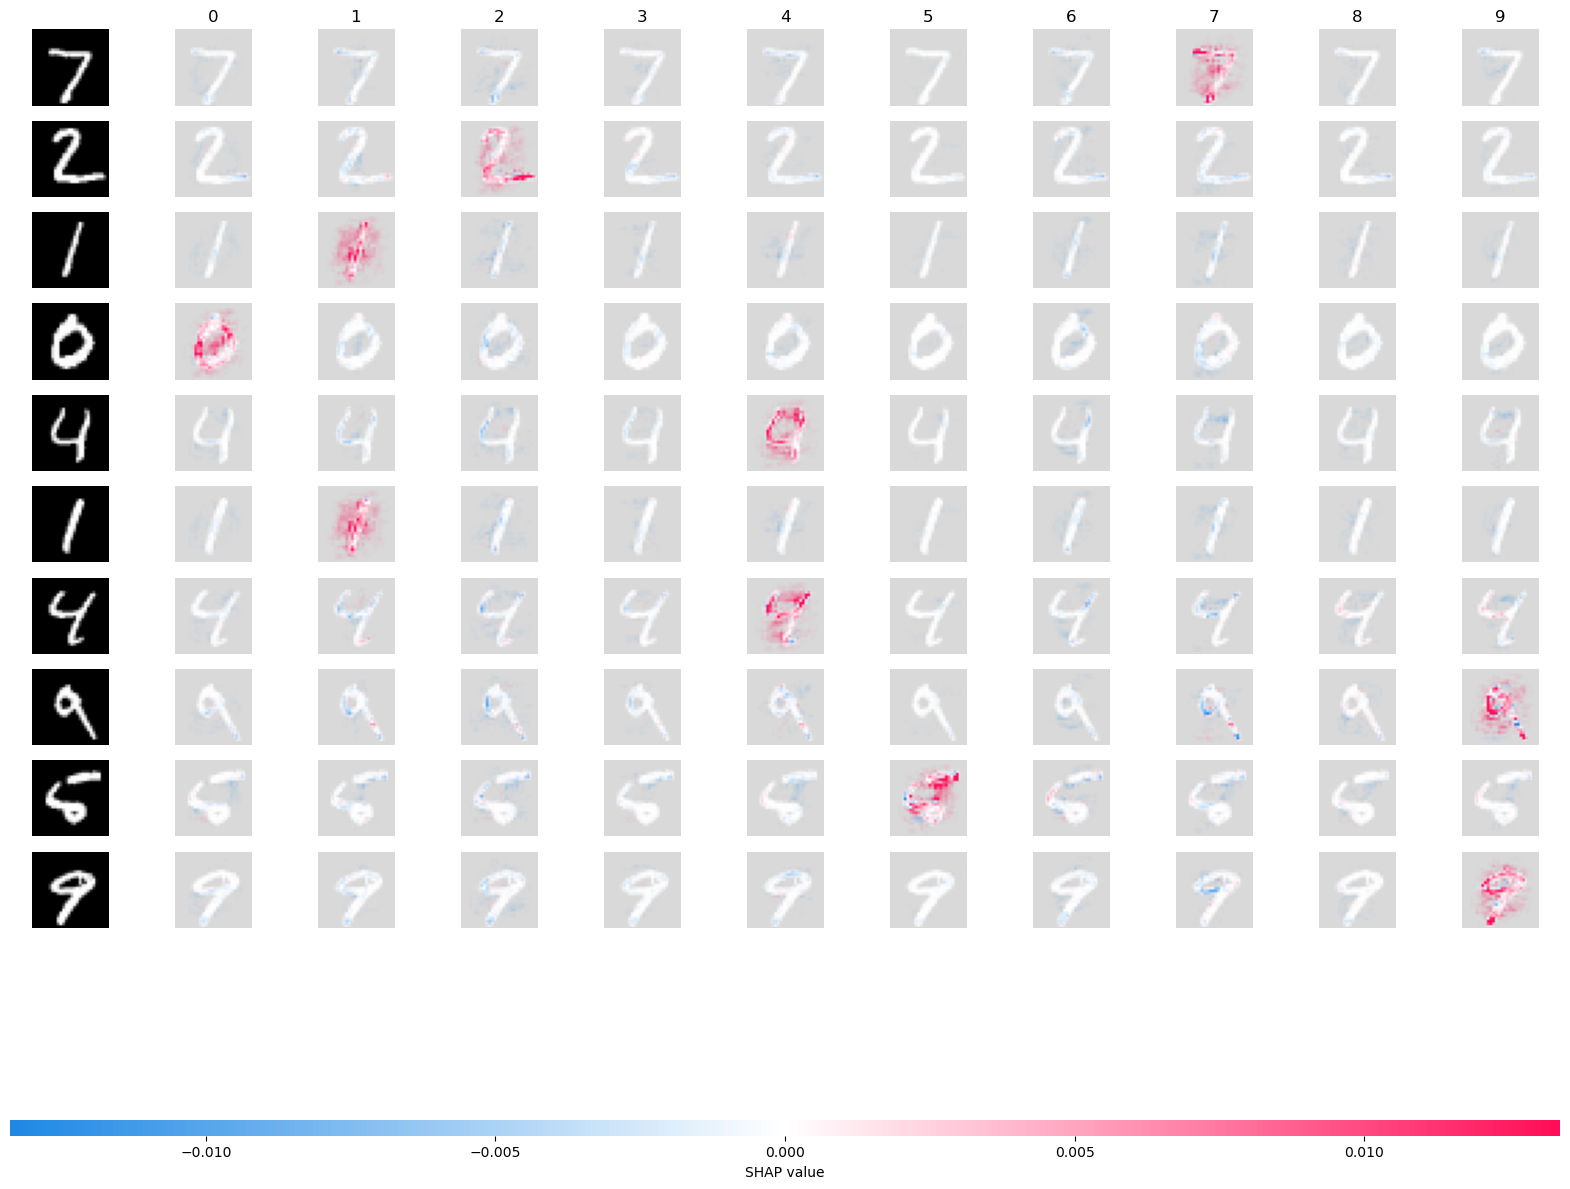

In [52]:
shap.plots.image(shap_value_list, test_data, labels = list(range(10)))

### 1. Grid Structure: Rows vs. Columns

* **The First Column (Far Left):** Displays the actual raw input image fed into the model (e.g., a handwritten $7$, $2$, $1$, $0$, etc.).
* **The Grid Columns (0–9):** Represent the model's output classes. Each column shows the SHAP explanation for that specific digit class.
* **Each Row:** Shows how the single input image on the left is evaluated against all 10 possible digit classes.

### 2. Interpreting the Colors (The SHAP Value Scale)

Look at the color bar at the bottom. The colors represent the impact of individual pixels on the model's prediction score for a given class:

* **Red Pixels (Positive SHAP Values):** These pixels **increase** the probability that the image belongs to that column's class. The model looks at these areas and thinks, *"This specific shape makes me think this is a [column number]."*
* **Blue Pixels (Negative SHAP Values):** These pixels **decrease** the probability that the image belongs to that column's class. The model looks at these areas and thinks, *"Because there is a mark/blank space here, it is less likely to be a [column number]."*
* **Grey/White Pixels (Zero SHAP Value):** These pixels have no influence on the classification decision.

### 3. Concrete Examples from the Image

To see this in action, let's analyze a couple of specific rows:

#### Row 1: Input is a "7"

* **Look at Column 7:** You will see a concentrated cluster of **vibrant red pixels** tracing the top and diagonal stroke of the digit. This indicates the model heavily relies on the exact shape of that handwritten stroke to classify it as a $7$.
* **Look at Column 9:** There might be faint blue or red features indicating why the model didn't choose $9$ (e.g., the absence of a closed loop at the top).

#### Row 2: Input is a "2"

* **Look at Column 2:** There is a distinct red signature at the base/loop of the $2$. This means the presence of ink in those areas is the strongest evidence for the class $2$.
* **Look at Column 3:** You can see some light activity because a handwritten $2$ shares structural similarities with a $3$, but the negative (blue) or lack of positive signals helps the model differentiate them.

#### Row 4: Input is a "0"

* **Look at Column 0:** There is a heavy ring of red pixels tracing the boundaries of the oval shape. The model recognizes the open center and the circular outer boundary as definitive proof of a $0$.
